# **Week2 복습과제**

**1. [ANN]**

**2. [CNN]**

- 데이터는 Week 1 과 같이 MNIST (0-9 숫자 분류) 데이터셋입니다.
- 이때, 우리의 복습과제에서는 0-4 숫자 분류를 위한 데이터 샘플만 사용할 예정입니다
- 아래 코드를 실행시켜 주세요

In [1]:
import torch
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader, Subset
import random

# Tensor 변환을 위함
transform = transforms.Compose([
    transforms.ToTensor()
])

# MNIST 데이터셋 불러오기
train_dataset = MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = MNIST(root='./data', train=False, transform=transform, download=True)

# 무작위로 샘플 인덱스 선택
train_indices = [i for i, label in enumerate(train_dataset.targets) if label in [0, 1, 2, 3, 4]]
test_indices = [i for i, label in enumerate(test_dataset.targets) if label in [0, 1, 2, 3, 4]]

# Subset을 사용하여 샘플링된 데이터셋 생성
train_subset = Subset(train_dataset, train_indices)
test_subset = Subset(test_dataset, test_indices)


# DataLoader 생성
batch_size = 64  # 배치 크기는 64로 설정 (batch_size를 다르게 실행해보셔도 좋습니다)
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 493kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.64MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.5MB/s]


In [2]:
# 데이터셋 크기 확인을 위해 해당 셀을 실행시켜 주세요
print(f"Train dataset size: {len(train_subset)}")
print(f"Test dataset size: {len(test_subset)}")

Train dataset size: 30596
Test dataset size: 5139


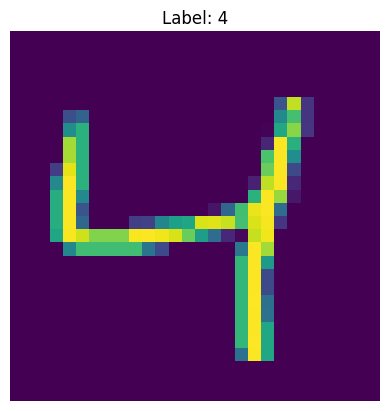

In [3]:
# 데이터셋 중 하나의 이미지를 시각화해보기
import matplotlib.pyplot as plt
import numpy as np

# 데이터셋에서 하나의 샘플 가져오기
image, label = train_subset[1]

# 텐서를 NumPy 배열로 변환
image = image.numpy().squeeze()

# 이미지 출력
plt.imshow(image)  # 이미지 표시
plt.title(f"Label: {label}")  # 레이블 표시
plt.axis("off")  # 축 없애기
plt.show()

<a id="1"></a> <br>
## **1. ANN**

**인공 신경망 (ANN)**

>  로지스틱 회귀는 분류 문제에서 성능이 좋지만, 데이터의 비선형성이 증가하면 모델의 정확도가 감소합니다.

>  따라서, hidden lyaer 에 더 많은 비선형 함수를 추가시켜 모델의 복잡도를 증가시켜 봅시다. 😀

↪ **3개의 hidden layer를 쌓고 다양한 활성화 함수 ReLU, Tanh, ELU 사용해봅시다**


In [4]:
# 필요한 라이브러리 임포트
import torch
import torch.nn as nn

#### **ANN 모델 생성**

In [5]:
# ANN Model
class ANNModel(nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim):
        super(ANNModel, self).__init__()

        # Linear function 1: ____ --> ____  (입력 차원에서 숨겨진 계층으로)
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        # Non-linearity 1 (ReLU 활성화 함수)
        self.relu1 = nn.ReLU()

        # Linear function 2: ____ --> ____  (숨겨진 계층을 한 번 더 통과)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        # Non-linearity 2 (Tanh 활성화 함수 사용)
        self.tanh2 = nn.Tanh()

        # Linear function 3: ____ --> ____  (추가 숨겨진 계층)
        self.fc3 = nn.Linear(hidden_dim,hidden_dim)
        # Non-linearity 3 (ELU 활성화 함수)
        self.elu3 = nn.ELU()

        # Linear function 4: ____ --> ____  (마지막 출력층)
        self.fc4 = nn.Linear(hidden_dim,output_dim)

    def forward(self, x):
        # Linear function 1
        out = self.fc1(x)
        # Non-linearity 1
        out = self.relu1(out)

        # Linear function 2
        out = self.fc2(out)
        # Non-linearity 2
        out = self.tanh2(out)

        # Linear function 3
        out = self.fc3(out)
        # Non-linearity 3
        out = self.elu3(out)

        # Linear function 4
        out = self.fc4(out)  # 마지막 출력층
        return out

In [9]:
# ANN 객체 생성
input_dim = 28*28  # 이미지 크기 (28x28)
hidden_dim = 150  # 하이퍼파라미터 (150으로 설정)
output_dim = 5  # 출력 클래스 개수 (0~4)


model = ANNModel(input_dim,hidden_dim,output_dim)
# 손실 함수 설정
loss_ftn = nn.CrossEntropyLoss() # 다중분류에 적합한 손실함수를 선택해주세요

# SGD Optimizer 사용 - 다른 옵티마이저를 사용해보셔도 됩니다 :)
learning_rate = 0.02
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

#### **ANN 모델 학습**

In [10]:
# ANN 모델 학습

# 학습을 모니터링하기 위한 변수들
count = 0  # 반복 횟수
loss_list = []  # Loss 저장 리스트
iteration_list = []  # Iteration 저장 리스트
accuracy_list = []  # 정확도 저장 리스트

# 전체 학습
for epoch in range(10):

    # 배치 단위 학습
    for i, (images, labels) in enumerate(train_loader):

        # 데이터를 모델 입력 형태로 변환 (2D 텐서로 펼치기)
        train = images.view(-1, 28*28)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
        labels = labels  # 텐서 형태 유지

        # 옵티마이저의 기울기 초기화
        optimizer.zero_grad()

        # Forward
        # 모델을 이용해 예측값(outputs) 계산
        outputs = model(train)

        # 손실 계산
        # cross entropy loss를 사용해 예측값과 실제값 비교
        loss = loss_ftn(outputs, labels)

        # Backward propagation - 손실에 대한 기울기 계산
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        count += 1  # 반복 횟수 증가

        if count % 50 == 0:
            # 정확도 계산을 위한 변수 초기화
            correct = 0
            total = 0


            # 모델이 테스트 데이터셋에서 얼마나 잘 예측하는지 확인
            for images, labels in test_loader:

                test = images.view(-1, 28*28)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
                # Forward
                # 예측값 계산
                outputs = model(test)

                # 예측값 중 가장 높은 값을 선택
                predicted = torch.max(outputs.data, 1)[1]

                # 총 샘플 개수
                total += len(labels)

                # 올바르게 예측한 개수
                correct += (predicted == labels).sum()

            # 정확도 계산
            accuracy = 100 * correct / float(total)

            # 손실 및 정확도 저장
            loss_list.append(loss.item())
            iteration_list.append(count)
            accuracy_list.append(accuracy)

        if count % 500 == 0:
            # 손실 및 정확도 출력
            print('Iteration: {}  Loss: {}  Accuracy: {} %'.format(count, loss.data, accuracy))


Iteration: 500  Loss: 0.16839778423309326  Accuracy: 96.380615234375 %
Iteration: 1000  Loss: 0.1906459480524063  Accuracy: 97.1978988647461 %
Iteration: 1500  Loss: 0.08142299205064774  Accuracy: 97.52870178222656 %
Iteration: 2000  Loss: 0.07766951620578766  Accuracy: 97.7232894897461 %
Iteration: 2500  Loss: 0.014874406158924103  Accuracy: 97.89842224121094 %
Iteration: 3000  Loss: 0.04632201045751572  Accuracy: 98.07355499267578 %
Iteration: 3500  Loss: 0.03323986753821373  Accuracy: 98.1319351196289 %
Iteration: 4000  Loss: 0.14038699865341187  Accuracy: 98.34598541259766 %
Iteration: 4500  Loss: 0.030692465603351593  Accuracy: 98.52111053466797 %


#### **ANN 학습 결과**

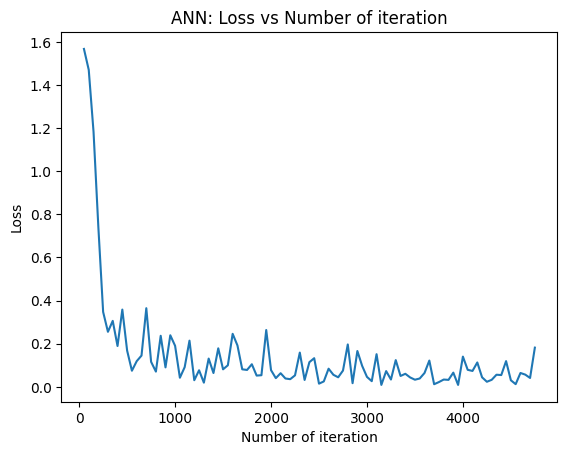

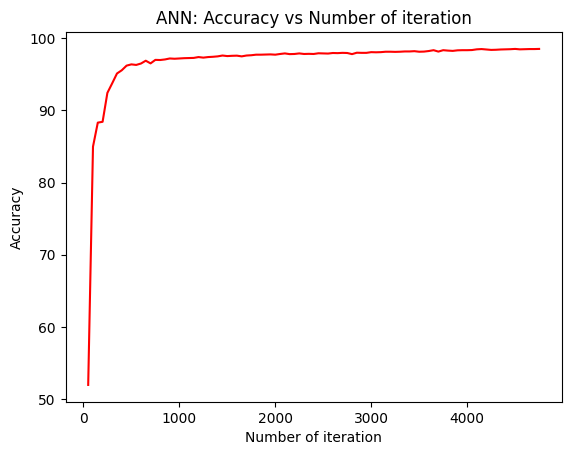

In [12]:
# loss 시각화
plt.plot(iteration_list,loss_list)
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("ANN: Loss vs Number of iteration")
plt.show()

# accuracy 시각화
plt.plot(iteration_list,accuracy_list,color = "red")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("ANN: Accuracy vs Number of iteration")
plt.show()

**해당 셀의 마크 다운을 풀고 시각화된 모델의 학습 결과를 해석해주세요.** 🤗



---
**[해석]**

-Loss vs Number of iteration
- 처음에는 Loss 값이 약 1.6 근처에서 시작 → 무작위 초기 가중치 상태라 예측 성능이 낮음.

- 학습이 진행될수록 Loss가 빠르게 감소 → 모델이 점점 데이터 패턴을 잘 학습하고 있다는 의미.

- 약 500 iteration 이후부터 Loss가 0.2 이하로 안정화 → 학습이 충분히 잘 이루어졌음을 의미.

- 이후에도 작은 진동이 보임 → 미니배치 학습의 특성

-Accuracy vs Number of iteration
- 초기 정확도는 약 50% 수준에서 시작

- 학습 초반 동안 정확도가 급격히 상승

- 이후 점차 상승 곡선이 완만해지며 95%에 수렴 → 높은 정확도.

#### **ANN 최적의 하이퍼파라미터 찾기**

1️⃣ **실험 1: Hidden Dimension 최적값 찾기**
- hidden_dim 값을 50-200 사이 값들로 설정하고 모델을 학습
- 각 hidden_dim 값에 대해 학습을 수행하면서 loss과 accuracy를 저장
- 모든 결과를 한 그래프에 표시하여 비교




2️⃣ **실험 2: Learning Rate 최적값 찾기**

- learning_rate 값을 0.1-0.005 사이 값들로 설정하고 모델을 학습
- 각 learning_rate 값에 대해 학습을 수행하면서 loss과 accuracy를 저장
- 모든 결과를 한 그래프에 표시하여 비교



**⚠ 이때 epoch 값은 자유롭게 해주셔도 됩니다! **

In [25]:
# 실험 1 hidden_dims=[50-200 사이 값들] 로 학습
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from collections import defaultdict

input_dim = 28*28  # 이미지 크기 (28x28)
hidden_dims = [50, 80, 100, 120, 150, 180, 200]
output_dim = 5  # 출력 클래스 개수 (0~4)
hidden_dims_list = {}

for hidden_dim in hidden_dims:
  model = ANNModel(input_dim,hidden_dim,output_dim)
  # 손실 함수 설정
  loss_ftn = nn.CrossEntropyLoss()

  learning_rate = 0.02
  optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

  # 학습을 모니터링하기 위한 변수들
  count = 0  # 반복 횟수
  loss_list = []  # Loss 저장 리스트
  iteration_list = []  # Iteration 저장 리스트
  accuracy_list = []  # 정확도 저장 리스트

  # 전체 학습
  for epoch in range(3):

      # 배치 단위 학습
      for i, (images, labels) in enumerate(train_loader):

          # 데이터를 모델 입력 형태로 변환 (2D 텐서로 펼치기)
          train = images.view(-1, 28*28)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
          labels = labels  # 텐서 형태 유지

          # 옵티마이저의 기울기 초기화
          optimizer.zero_grad()

          # Forward
          # 모델을 이용해 예측값(outputs) 계산
          outputs = model(train)

          # 손실 계산
          # cross entropy loss를 사용해 예측값과 실제값 비교
          loss = loss_ftn(outputs, labels)

          # Backward propagation - 손실에 대한 기울기 계산
          loss.backward()

          # 가중치 업데이트
          optimizer.step()

          count += 1  # 반복 횟수 증가

          if count % 50 == 0:
              # 정확도 계산을 위한 변수 초기화
              correct = 0
              total = 0


              # 모델이 테스트 데이터셋에서 얼마나 잘 예측하는지 확인
              for images, labels in test_loader:

                  test = images.view(-1, 28*28)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
                  # Forward
                  # 예측값 계산
                  outputs = model(test)

                  # 예측값 중 가장 높은 값을 선택
                  predicted = torch.max(outputs.data, 1)[1]

                  # 총 샘플 개수
                  total += len(labels)

                  # 올바르게 예측한 개수
                  correct += (predicted == labels).sum()

              # 정확도 계산
              accuracy = 100 * correct / float(total)

              # 손실 및 정확도 저장
              loss_list.append(loss.item())
              iteration_list.append(count)
              accuracy_list.append(accuracy)

          if count % 500 == 0:
              # 손실 및 정확도 출력
              print('Iteration: {}  Loss: {}  Accuracy: {} %'.format(count, loss.data, accuracy))
  hidden_dims_list[hidden_dim] = (loss_list,accuracy_list)


Iteration: 500  Loss: 0.15491673350334167  Accuracy: 95.11578369140625 %
Iteration: 1000  Loss: 0.1319689154624939  Accuracy: 96.94493103027344 %
Iteration: 500  Loss: 0.19149470329284668  Accuracy: 96.18602752685547 %
Iteration: 1000  Loss: 0.0650569275021553  Accuracy: 97.06168365478516 %
Iteration: 500  Loss: 0.1387683004140854  Accuracy: 96.18602752685547 %
Iteration: 1000  Loss: 0.24817700684070587  Accuracy: 97.02276611328125 %
Iteration: 500  Loss: 0.1127927377820015  Accuracy: 96.3222427368164 %
Iteration: 1000  Loss: 0.08189677447080612  Accuracy: 97.08114624023438 %
Iteration: 500  Loss: 0.11862540990114212  Accuracy: 96.26386260986328 %
Iteration: 1000  Loss: 0.09765171259641647  Accuracy: 97.23681640625 %
Iteration: 500  Loss: 0.14499524235725403  Accuracy: 96.04981231689453 %
Iteration: 1000  Loss: 0.0922190472483635  Accuracy: 97.08114624023438 %
Iteration: 500  Loss: 0.2068900763988495  Accuracy: 96.12765502929688 %
Iteration: 1000  Loss: 0.08324695378541946  Accuracy: 9

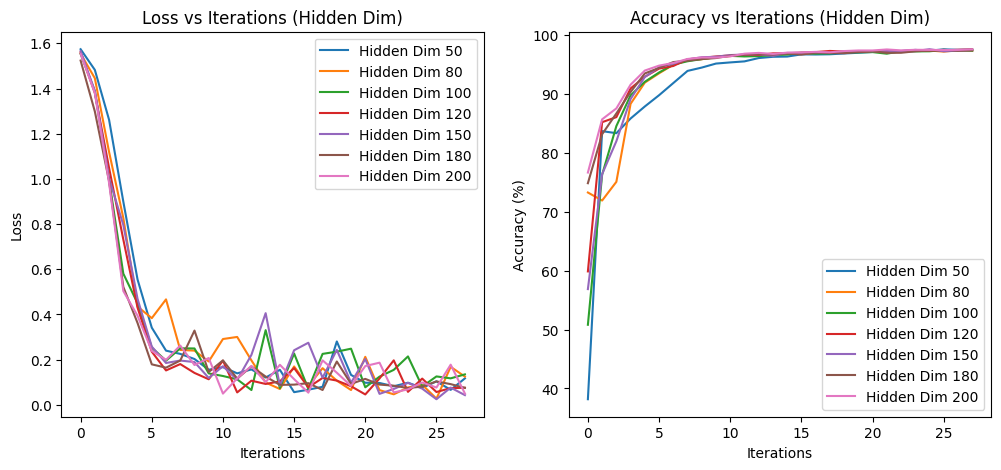

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Loss 그래프
plt.subplot(1,2,1)
for h in hidden_dims_list:
    loss_list, acc_list = hidden_dims_list[h]
    plt.plot(range(len(loss_list)), loss_list, label=f'Hidden Dim {h}')
plt.title('Loss vs Iterations (Hidden Dim)')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()

# Accuracy 그래프
plt.subplot(1,2,2)
for h in hidden_dims_list:
    loss_list, acc_list = hidden_dims_list[h]
    plt.plot(range(len(acc_list)), acc_list, label=f'Hidden Dim {h}')
plt.title('Accuracy vs Iterations (Hidden Dim)')
plt.xlabel('Iterations')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.show()


**해당 셀의 마크 다운을 풀고 hidden dimension 값이 모델의 학습에 주는 영향을 설명해주세요.** 🤗



---
**[답변]**

-Loss vs Iterations
- hidden_dim=50인 경우 초기 손실값이 조금 더 천천히 내려가며, 진동 폭이 큼.

- hidden_dim=100~200 구간에서는 loss 감소 속도가 빠르고 더 안정적으로 수렴

-Accuracy vs Iterations
- hidden_dim=50 → 초반 정확도가 낮고 상승 속도가 느림.

- hidden_dim=100~200 → 정확도가 빠르게 올라가고 95% 이상에서 안정적으로 수렴.

In [38]:
# 실험 2 learning_rates=[0.1-0.005 사이 값들] 로 학습
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from collections import defaultdict

input_dim = 28*28  # 이미지 크기 (28x28)
hidden_dims = 150
output_dim = 5  # 출력 클래스 개수 (0~4)
model = ANNModel(input_dim,hidden_dim,output_dim)
loss_ftn = nn.CrossEntropyLoss()
learning_rates = [0.1, 0.05, 0.025, 0.0125, 0.006]
learning_rates_list = {}

for learning_rate in learning_rates:

  optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

  # 학습을 모니터링하기 위한 변수들
  count = 0  # 반복 횟수
  loss_list = []  # Loss 저장 리스트
  iteration_list = []  # Iteration 저장 리스트
  accuracy_list = []  # 정확도 저장 리스트

  # 전체 학습
  for epoch in range(3):

      # 배치 단위 학습
      for i, (images, labels) in enumerate(train_loader):

          # 데이터를 모델 입력 형태로 변환 (2D 텐서로 펼치기)
          train = images.view(-1, 28*28)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
          labels = labels  # 텐서 형태 유지

          # 옵티마이저의 기울기 초기화
          optimizer.zero_grad()

          # Forward
          # 모델을 이용해 예측값(outputs) 계산
          outputs = model(train)

          # 손실 계산
          # cross entropy loss를 사용해 예측값과 실제값 비교
          loss = loss_ftn(outputs, labels)

          # Backward propagation - 손실에 대한 기울기 계산
          loss.backward()

          # 가중치 업데이트
          optimizer.step()

          count += 1  # 반복 횟수 증가

          if count % 50 == 0:
              # 정확도 계산을 위한 변수 초기화
              correct = 0
              total = 0


              # 모델이 테스트 데이터셋에서 얼마나 잘 예측하는지 확인
              for images, labels in test_loader:

                  test = images.view(-1, 28*28)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
                  # Forward
                  # 예측값 계산
                  outputs = model(test)

                  # 예측값 중 가장 높은 값을 선택
                  predicted = torch.max(outputs.data, 1)[1]

                  # 총 샘플 개수
                  total += len(labels)

                  # 올바르게 예측한 개수
                  correct += (predicted == labels).sum()

              # 정확도 계산
              accuracy = 100 * correct / float(total)

              # 손실 및 정확도 저장
              loss_list.append(loss.item())
              iteration_list.append(count)
              accuracy_list.append(accuracy)

          if count % 500 == 0:
              # 손실 및 정확도 출력
              print('Iteration: {}  Loss: {}  Accuracy: {} %'.format(count, loss.data, accuracy))
  learning_rates_list[learning_rate] = (loss_list,accuracy_list)


Iteration: 500  Loss: 0.049689073115587234  Accuracy: 97.33411407470703 %
Iteration: 1000  Loss: 0.021827444434165955  Accuracy: 98.5794906616211 %
Iteration: 500  Loss: 0.02372230589389801  Accuracy: 99.06596374511719 %
Iteration: 1000  Loss: 0.021080395206809044  Accuracy: 99.1048812866211 %
Iteration: 500  Loss: 0.0035000948701053858  Accuracy: 99.22164154052734 %
Iteration: 1000  Loss: 0.008178357034921646  Accuracy: 99.33839416503906 %
Iteration: 500  Loss: 0.004392002709209919  Accuracy: 99.28001403808594 %
Iteration: 1000  Loss: 0.010148770175874233  Accuracy: 99.29947662353516 %
Iteration: 500  Loss: 0.014847321435809135  Accuracy: 99.33839416503906 %
Iteration: 1000  Loss: 0.0032971068285405636  Accuracy: 99.33839416503906 %


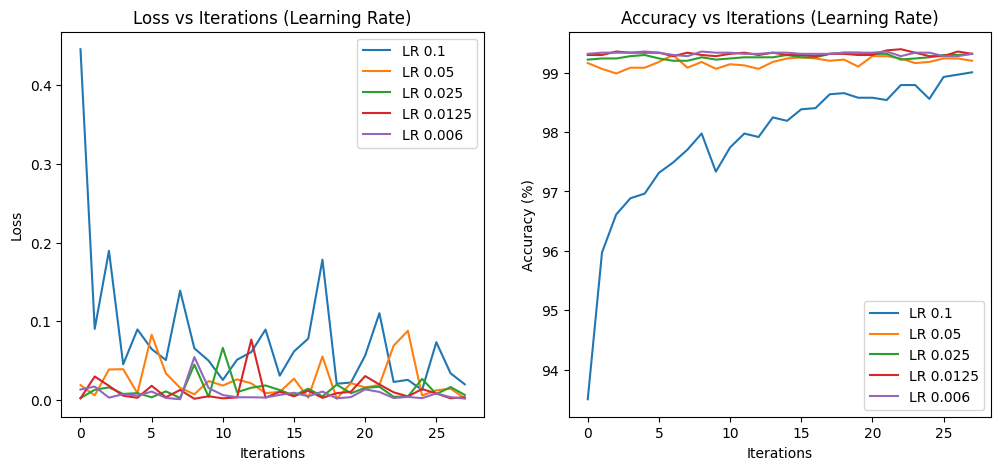

In [39]:
# 실험 2 모델 학습 결과 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Loss 그래프
plt.subplot(1,2,1)
for lr in learning_rates:
    loss_list, acc_list = learning_rates_list[lr]
    plt.plot(range(len(loss_list)), loss_list, label=f'LR {lr}')
plt.title('Loss vs Iterations (Learning Rate)')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()

# Accuracy 그래프
plt.subplot(1,2,2)
for lr in learning_rates:
    loss_list, acc_list = learning_rates_list[lr]
    plt.plot(range(len(acc_list)), acc_list, label=f'LR {lr}')
plt.title('Accuracy vs Iterations (Learning Rate)')
plt.xlabel('Iterations')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.show()


**해당 셀의 마크 다운을 풀고 learning rate 값이 모델의 학습에 주는 영향을 설명해주세요.** 🤗



---
**[답변]**

Loss vs Iterations
- LR = 0.1 : Loss가 빠르게 줄지만 진동이 크고 불안정함, 최적값 근처에서 오르락내리락하며 안정적으로 수렴하지 못함.
- LR = 0.05 : Loss가 줄어들지만 변동성이 다소 있음, 비교적 빠른 학습이 가능하지만 여전히 완전 안정적이지 않음.
- LR = 0.025, 0.0125, 0.006 : Loss가 매우 안정적으로 줄어들며 거의 0에 가까운 값으로 수렴, 진동이 거의 없고 부드러운 학습 곡선을 그림. 단, LR이 너무 작을 경우(0.006) → 수렴 속도가 조금 느림

Accuracy vs Iterations
- LR = 0.1 : 정확도가 꾸준히 올라가지만, 다른 learning rate보다 낮은 정확도에 머무름
- LR = 0.05 : 비교적 빠르게 99% 근처까지 도달하지만 중간에 변동 있음.
- LR = 0.025, 0.0125, 0.006 : 정확도가 매우 안정적으로 99% 이상에 도달.
- 특히 0.0125와 0.025는 빠른 수렴 + 높은 정확도를 보이며 가장 적합한 learning rate로 보임.

<a id="1"></a> <br>
## **2. CNN**
> CNN은 이미지 분류에 적합한 모델로, kernel을 이용해 feature map을 생성합니다

**↪ 2개의 합성곱 계층을 쌓고, 활성화 함수로 ReLU를 사용하며,Max Pooling layer를 적용해봅시다.**

#### **CNN 모델 생성**

In [48]:
import torch
import torch.nn as nn
import torch.optim as optim

# CNN Model 정의
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        # 합성곱 계층 1 (Conv Layer 1)
        self.cnn1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5, stride=1, padding=0)
        self.relu1 = nn.ReLU()  # 활성화 함수 (ReLU)

        # Max Pooling 1
        self.maxpool1 = nn.MaxPool2d(kernel_size=2)  # kernel size를 2로 설정

        # 합성곱 계층 2 (Conv Layer 2)
        self.cnn2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=0)
        self.relu2 = nn.ReLU()  # 활성화 함수 (ReLU)

        # Max Pooling 2
        self.maxpool2 = nn.MaxPool2d(kernel_size=2) # kernel size를 2로 설정

        # Fully Connected Layer
        self.fc1 = nn.Linear(32*4*4, 10)  # 입력 차원 및 출력 차원 지정

    def forward(self, x):
        # 합성곱 계층 1 + 활성화 함수
        out = self.cnn1(x)
        out = self.relu1(out)

        # Max Pooling 1
        out = self.maxpool1(out)

        # 합성곱 계층 2 + 활성화 함수
        out = self.cnn2(out)
        out = self.relu2(out)

        # Max Pooling 2
        out = self.maxpool2(out)

        # feature map을 flatten하게
        out = out.view(out.size(0),-1)

        # 완전 연결 계층
        out = self.fc1(out)

        return out


In [49]:
# CNN 객체 생성
model = CNNModel()
# 손실 함수 설정
loss_ftn = nn.CrossEntropyLoss()  # 다중분류에 적합한 손실함수를 선택해주세요

# SGD Optimizer 사용 - 다른 옵티마이저를 사용해보셔도 됩니다 :)
optimizer = optim.SGD(model.parameters(), lr=0.001)  # 학습률을 자유롭게 설정해주세요

#### **CNN 모델 학습**

In [50]:
# CNN 모델 학습

# 학습을 모니터링하기 위한 변수들
count = 0  # 반복 횟수
loss_list = []  # Loss 저장 리스트
iteration_list = []  # Iteration 저장 리스트
accuracy_list = []  # 정확도 저장 리스트
num_epochs = 20  # 학습할 에포크 수 설정 -> 자유롭게 설정해주셔도 됩니다

for epoch in range(num_epochs):
    running_loss = 0.0  # 에포크별 손실 초기화

    for images, labels in train_loader:
        # 옵티마이저의 기울기 초기화
        optimizer.zero_grad()

        # Forward
        outputs = model(images)

        # 손실 계산
        loss = loss_ftn(outputs,labels)

        # Backward
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        # 손실 누적
        running_loss += loss.item()
        count += 1  # 반복 횟수 증가

        if count % 50 == 0:
            correct = 0
            total = 0

            with torch.no_grad():  # 평가
                for images, labels in test_loader:
                    # 모델 예측 수행
                    outputs = model(images)

                    # 가장 확률이 높은 클래스 선택
                    predicted = torch.max(outputs.data,1)[1]

                    # 총 샘플 수 및 올바른 예측 개수 누적
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()

            # 정확도 계산
            accuracy = 100 * correct / float(total)

            # 손실 및 정확도 저장
            loss_list.append(loss.item())
            iteration_list.append(count)
            accuracy_list.append(accuracy)

    # 매 에포크마다 평균 손실 출력
    print(f"Epoch {epoch+1}, Loss: {running_loss / len(train_loader)}")

Epoch 1, Loss: 1.834359603037665
Epoch 2, Loss: 0.9758156955491029
Epoch 3, Loss: 0.4237798903456312
Epoch 4, Loss: 0.25897322030493014
Epoch 5, Loss: 0.20557228377816075
Epoch 6, Loss: 0.1808985600438521
Epoch 7, Loss: 0.16682246174966617
Epoch 8, Loss: 0.1581593456917242
Epoch 9, Loss: 0.1505382728543218
Epoch 10, Loss: 0.14525154117875905
Epoch 11, Loss: 0.14084650431847148
Epoch 12, Loss: 0.13700772646915688
Epoch 13, Loss: 0.13296347853702362
Epoch 14, Loss: 0.1299962367481379
Epoch 15, Loss: 0.12728067259994455
Epoch 16, Loss: 0.12462455357982931
Epoch 17, Loss: 0.12214269002195689
Epoch 18, Loss: 0.1199004041392644
Epoch 19, Loss: 0.1176294304959336
Epoch 20, Loss: 0.11606368638326206


#### **CNN 학습 결과**

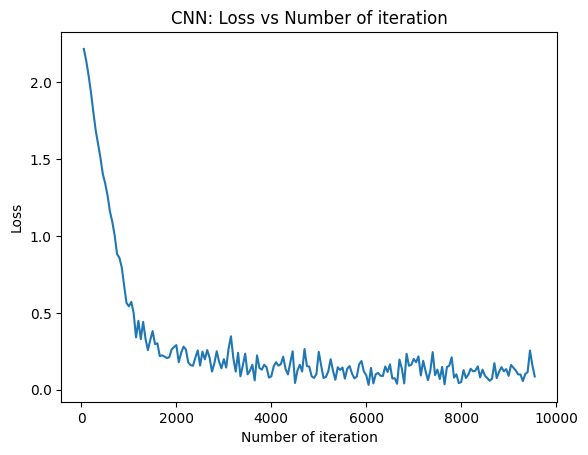

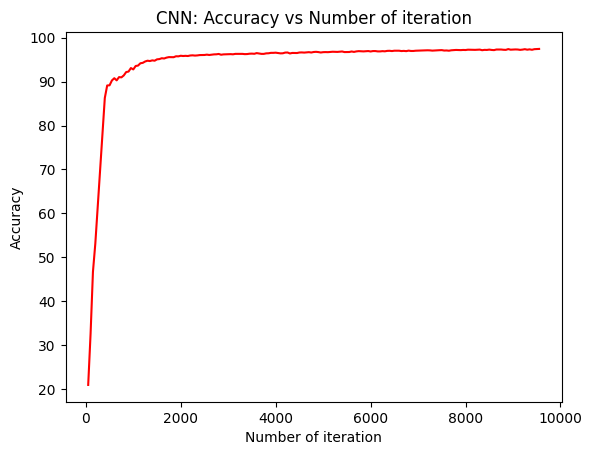

In [51]:
# loss 시각화
plt.plot(iteration_list,loss_list)
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("CNN: Loss vs Number of iteration")
plt.show()

# accuracy 시각화
plt.plot(iteration_list,accuracy_list,color = "red")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("CNN: Accuracy vs Number of iteration")
plt.show()

**해당 셀의 마크 다운을 풀고 MNIST 데이터셋에서 ANN, CNN의 학습 결과 비교와 함께 두 모델에 대해 각각 짧게 소개해주세요.** 🤗



---
**[답변]**

-ANN
- 특징
  - 입력층 → 은닉층 → 출력층 으로 구성된 전형적인 다층 퍼셉트론 구조.
  - 모든 입력 노드가 은닉층의 모든 노드와 연결되는 완전 연결 구조.
  - 이미지와 같은 2D 데이터를 다룰 때는 데이터를 1차원 벡터로 펼쳐서 학습해야 함 → 공간적 구조를 잃음.
- 학습 결과
  - Loss: 빠르게 감소 후 안정적으로 0.05 근처에 수렴.
  - Accuracy: 약 98% 수준에서 수렴
  - 비교적 단순한 구조지만 MNIST(숫자 이미지) 데이터에 대해서는 좋은 성능을 보임.

-CNN (Convolutional Neural Network)
- 특징
  - 합성곱 계층: 이미지의 지역적 특징을 자동으로 추출.
  - Pooling 계층: 특징 맵의 크기를 줄여 계산량 감소 + 불필요한 정보 제거.
  - Fully Connected Layer를 통해 최종 분류.
  - 이미지의 공간적 구조를 보존하며 학습하기 때문에 시각 데이터에 매우 강력.

- 학습 결과
  - Loss: 더 낮은 값까지 감소하면서 안정적.
  - Accuracy: ANN과 비슷
